# Marketing Mix Modeling — Amazon Ads Pipeline

This notebook builds a Marketing Mix Model (MMM) on top of the Amazon Ads warehouse.

## What this does
- Loads weekly spend + sales data generated by `src/mmm_prep.py`
- Applies **adstock** and **Hill saturation** transforms to model ad carry-over and diminishing returns
- Fits an OLS MMM to decompose sales into: baseline organic + SP contribution + SB contribution + DSP contribution + seasonality
- Validates the model against known true parameters (synthetic data advantage)
- Outputs a **budget optimizer**: given total spend, what's the optimal channel split?

## Important note on data
The dataset used here is **synthetic** (104 weeks, generated by `src/mmm_prep.py`).  
The real warehouse contains ~5 weeks of data — insufficient for causal inference.  
The pipeline, transforms, and model code are production-ready; swap in real data with ≥52 weeks and re-run.

---
**Stack:** Python · pandas · numpy · scikit-learn · matplotlib · scipy  
**MMM approach:** Frequentist OLS with manual adstock + Hill saturation  
**Next step:** Bayesian version with PyMC for uncertainty quantification


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from pathlib import Path

# Paths
DATA_DIR = Path("..") / "data" / "mmm"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F8F8",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CHANNEL_COLORS = {
    "spend_sp":  "#2C5F3E",
    "spend_sb":  "#4A8B62",
    "spend_dsp": "#A8D5B5",
    "baseline":  "#E8E0D0",
    "seasonality": "#C4956A",
}

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Load synthetic weekly data
df = pd.read_csv(DATA_DIR / "weekly_synthetic.csv", parse_dates=["week_start"])
true_params = pd.read_csv(DATA_DIR / "true_parameters.csv")

print(f"Dataset: {len(df)} weeks ({df['week_start'].min().date()} → {df['week_start'].max().date()})")
print(f"\nTrue parameters (for validation):")
print(true_params.to_string(index=False))
print(f"\nSample data:")
df[["week_start", "spend_sp", "spend_sb", "spend_dsp", "total_sales", "tacos"]].head(8)


Dataset: 104 weeks (2023-01-02 → 2024-12-23)

True parameters (for validation):
   param  value                             description
 beta_sp    3.5 Sponsored Products response coefficient
 beta_sb    2.0   Sponsored Brands response coefficient
beta_dsp    1.2                DSP response coefficient
baseline 8000.0              Weekly organic sales floor

Sample data:


,week_start,spend_sp,spend_sb,spend_dsp,total_sales,tacos
0,2023-01-02,1622.21,634.30,418.34,8617.63,0.310
1,2023-01-09,1413.05,748.45,484.29,10095.51,0.262
2,2023-01-16,1828.04,677.51,628.80,11448.24,0.274
3,2023-01-23,1949.18,793.21,421.09,11487.87,0.275
4,2023-01-30,1406.82,1005.18,591.18,11528.43,0.261
5,2023-02-06,1630.05,660.36,562.10,11321.11,0.252
6,2023-02-13,2066.50,1047.67,611.27,13655.33,0.273
7,2023-02-20,2063.98,1070.59,815.61,15196.73,0.260


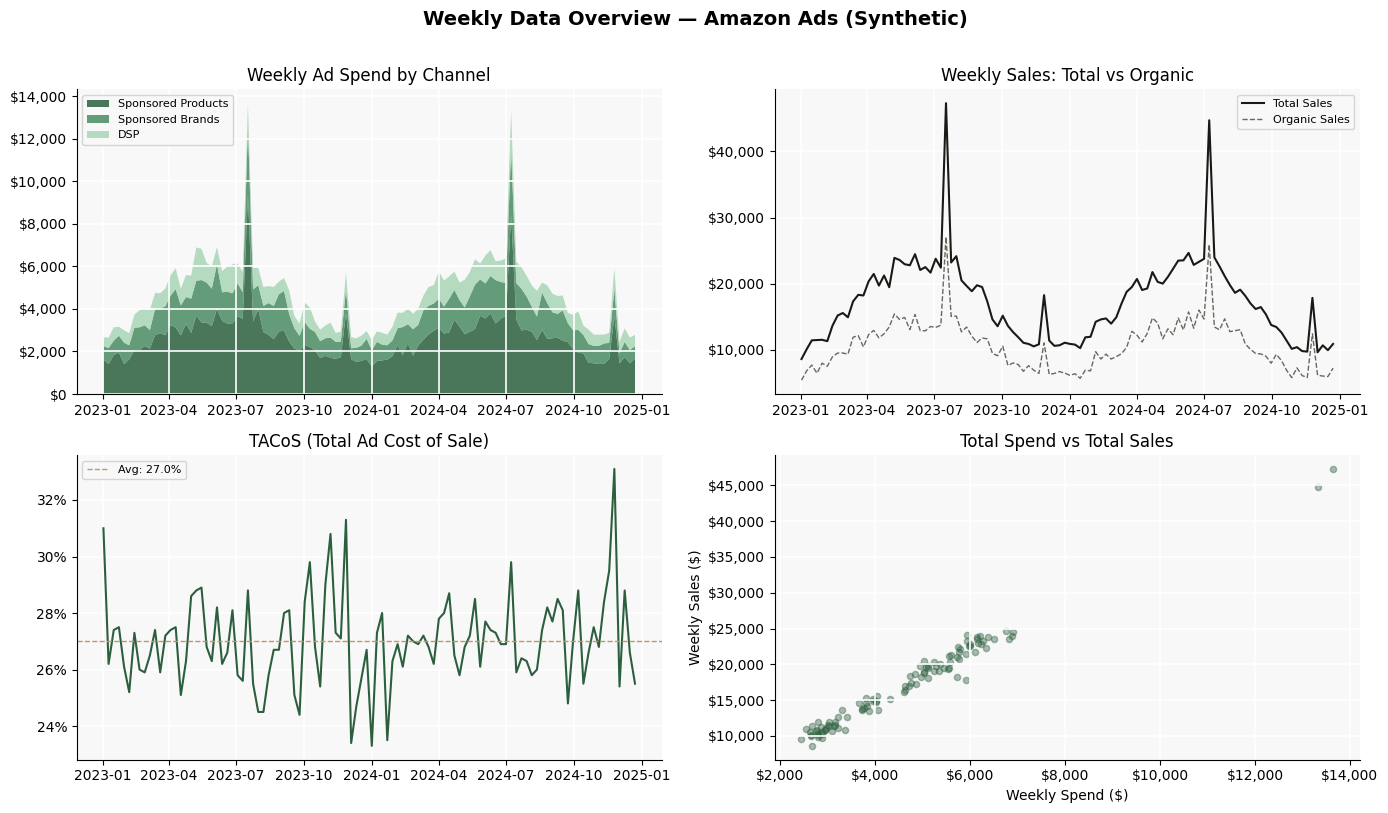

EDA chart saved.


In [3]:
# ── Exploratory Data Analysis ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Weekly Data Overview — Amazon Ads (Synthetic)", fontsize=14, fontweight="bold", y=1.01)

dollar_fmt = FuncFormatter(lambda x, _: f"${x:,.0f}")
pct_fmt    = FuncFormatter(lambda x, _: f"{x:.0%}")

# 1. Spend by channel
ax = axes[0, 0]
ax.stackplot(df["week_start"],
             df["spend_sp"], df["spend_sb"], df["spend_dsp"],
             labels=["Sponsored Products", "Sponsored Brands", "DSP"],
             colors=[CHANNEL_COLORS["spend_sp"], CHANNEL_COLORS["spend_sb"], CHANNEL_COLORS["spend_dsp"]],
             alpha=0.85)
ax.set_title("Weekly Ad Spend by Channel")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(loc="upper left", fontsize=8)

# 2. Total sales
ax = axes[0, 1]
ax.plot(df["week_start"], df["total_sales"], color="#1A1915", linewidth=1.5, label="Total Sales")
ax.plot(df["week_start"], df["organic_sales"], color="#6B6760", linewidth=1, linestyle="--", label="Organic Sales")
ax.set_title("Weekly Sales: Total vs Organic")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(fontsize=8)

# 3. TACoS over time
ax = axes[1, 0]
ax.plot(df["week_start"], df["tacos"], color=CHANNEL_COLORS["spend_sp"], linewidth=1.5)
ax.axhline(df["tacos"].mean(), color="#C4956A", linestyle="--", linewidth=1, label=f"Avg: {df['tacos'].mean():.1%}")
ax.set_title("TACoS (Total Ad Cost of Sale)")
ax.yaxis.set_major_formatter(pct_fmt)
ax.legend(fontsize=8)

# 4. Spend vs Sales scatter
ax = axes[1, 1]
ax.scatter(df["spend_total"], df["total_sales"], alpha=0.4, color=CHANNEL_COLORS["spend_sp"], s=20)
ax.set_title("Total Spend vs Total Sales")
ax.set_xlabel("Weekly Spend ($)")
ax.set_ylabel("Weekly Sales ($)")
ax.xaxis.set_major_formatter(dollar_fmt)
ax.yaxis.set_major_formatter(dollar_fmt)

plt.tight_layout()
plt.savefig(DATA_DIR / "01_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA chart saved.")


In [4]:
# ── Adstock + Hill Saturation Transforms ───────────────────────────────────
# These are the core MMM transforms. We apply them before fitting the model.

def adstock_geometric(x: np.ndarray, decay: float) -> np.ndarray:
    """Geometric adstock: each week carries forward `decay` fraction of prior."""
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + decay * out[i - 1]
    return out

def hill_saturation(x: np.ndarray, K: float, n: float = 2.0) -> np.ndarray:
    """Hill function: diminishing returns. K = half-saturation point."""
    return x**n / (K**n + x**n)

# Apply transforms with fixed params (grid search / Bayesian inference in production)
ADSTOCK_PARAMS = {"spend_sp": 0.5, "spend_sb": 0.3, "spend_dsp": 0.7}
HILL_K_PARAMS  = {"spend_sp": 3000, "spend_sb": 1500, "spend_dsp": 1000}

for ch, decay in ADSTOCK_PARAMS.items():
    df[f"adstock_{ch}"]     = adstock_geometric(df[ch].values, decay)
    df[f"saturated_{ch}"]   = hill_saturation(df[f"adstock_{ch}"].values, K=HILL_K_PARAMS[ch])
    df[f"transformed_{ch}"] = df[f"saturated_{ch}"] * df[ch]  # saturation × raw spend

# Seasonality feature: week-of-year sine/cosine
df["season_sin"] = np.sin(2 * np.pi * df["week"] / 52)
df["season_cos"] = np.cos(2 * np.pi * df["week"] / 52)

print("Transforms applied:")
print(f"  Adstock decays:    SP={ADSTOCK_PARAMS['spend_sp']} | SB={ADSTOCK_PARAMS['spend_sb']} | DSP={ADSTOCK_PARAMS['spend_dsp']}")
print(f"  Hill K (half-sat): SP={HILL_K_PARAMS['spend_sp']} | SB={HILL_K_PARAMS['spend_sb']} | DSP={HILL_K_PARAMS['spend_dsp']}")
df[["week_start","transformed_spend_sp","transformed_spend_sb","transformed_spend_dsp"]].head(5)


Transforms applied:
  Adstock decays:    SP=0.5 | SB=0.3 | DSP=0.7
  Hill K (half-sat): SP=3000 | SB=1500 | DSP=1000


,week_start,transformed_spend_sp,transformed_spend_sb,transformed_spend_dsp
0,2023-01-02,367.014363,96.217820,62.308489
1,2023-01-09,501.199948,210.638660,182.349999
2,2023-01-16,895.593347,196.617525,364.090639
3,2023-01-23,1101.349744,271.125009,255.480629
4,2023-01-30,730.182095,442.225918,402.508420


In [5]:
# ── Fit OLS Marketing Mix Model ─────────────────────────────────────────────

FEATURES = ["transformed_spend_sp", "transformed_spend_sb", "transformed_spend_dsp",
            "season_sin", "season_cos"]
TARGET   = "total_sales"

X = df[FEATURES].values
y = df[TARGET].values

model = LinearRegression(fit_intercept=True)
model.fit(X, y)

y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)

print(f"Model fit:  R² = {r2:.3f}  |  MAPE = {mape:.1%}")
print(f"\nBaseline (intercept): ${model.intercept_:,.0f}/week")
print("\nCoefficients:")
for feat, coef in zip(FEATURES, model.coef_):
    print(f"  {feat:<35} {coef:+.4f}")

print(f"\nTrue betas for reference:")
for _, row in true_params[true_params['param'].str.startswith('beta')].iterrows():
    print(f"  {row['param']:<12} true={row['value']}")


Model fit:  R² = 0.995  |  MAPE = 2.3%

Baseline (intercept): $8,217/week

Coefficients:
  transformed_spend_sp                +3.6159
  transformed_spend_sb                +1.8137
  transformed_spend_dsp               +0.7435
  season_sin                          +691.6265
  season_cos                          -1407.6997

True betas for reference:
  beta_sp      true=3.5
  beta_sb      true=2.0
  beta_dsp     true=1.2


In [6]:
# ── Sales Decomposition ──────────────────────────────────────────────────────
# Break total sales into: baseline + SP contribution + SB contribution + DSP + seasonality

df["contrib_baseline"]    = model.intercept_
df["contrib_sp"]          = model.coef_[0] * df["transformed_spend_sp"]
df["contrib_sb"]          = model.coef_[1] * df["transformed_spend_sb"]
df["contrib_dsp"]         = model.coef_[2] * df["transformed_spend_dsp"]
df["contrib_seasonality"] = model.coef_[3] * df["season_sin"] + model.coef_[4] * df["season_cos"]
df["y_pred"]              = y_pred

# Sanity check: contributions sum to predicted sales
check = (df[["contrib_baseline","contrib_sp","contrib_sb","contrib_dsp","contrib_seasonality"]].sum(axis=1) - df["y_pred"]).abs().max()
print(f"Decomposition check (max residual): {check:.4f}  ✓" if check < 1 else f"⚠ Decomposition error: {check}")

# Percentage of total sales by source
total = df["total_sales"].sum()
shares = {
    "Baseline organic":     df["contrib_baseline"].sum()    / total,
    "Sponsored Products":   df["contrib_sp"].sum()          / total,
    "Sponsored Brands":     df["contrib_sb"].sum()          / total,
    "DSP":                  df["contrib_dsp"].sum()         / total,
    "Seasonality":          df["contrib_seasonality"].sum() / total,
}
print("\nSales decomposition (% of total):")
for k, v in shares.items():
    bar = "█" * int(v * 40)
    print(f"  {k:<25} {v:>6.1%}  {bar}")


Decomposition check (max residual): 0.0000  ✓

Sales decomposition (% of total):
  Baseline organic           47.4%  ██████████████████
  Sponsored Products         41.7%  ████████████████
  Sponsored Brands            7.8%  ███
  DSP                         3.0%  █
  Seasonality                 0.0%  


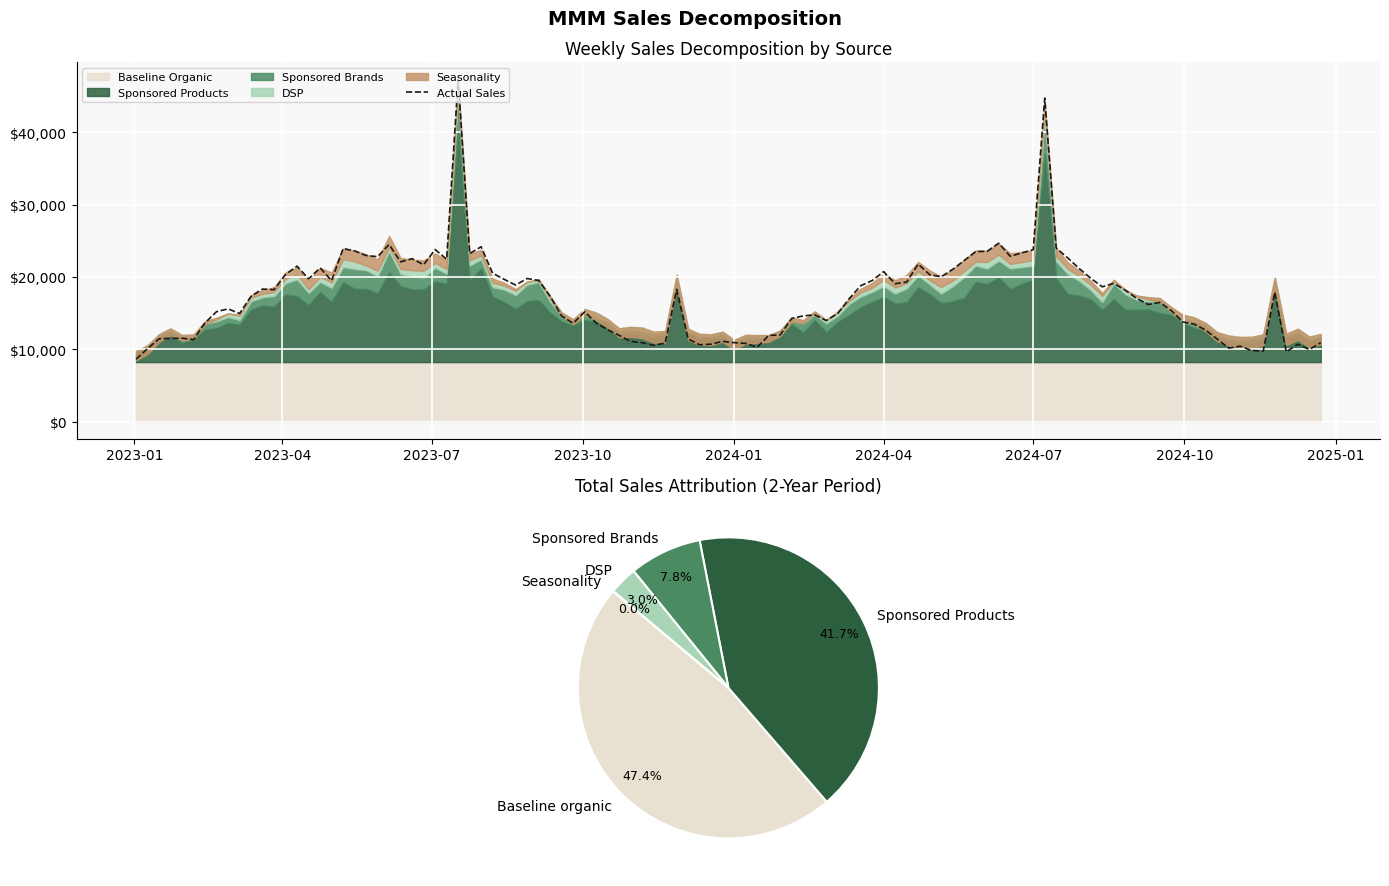

Decomposition chart saved.


In [7]:
# ── Contribution Chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("MMM Sales Decomposition", fontsize=14, fontweight="bold")

dollar_fmt = FuncFormatter(lambda x, _: f"${x:,.0f}")

# Top: stacked area — decomposed sales
ax = axes[0]
bottom = np.zeros(len(df))
layers = [
    ("contrib_baseline",    "Baseline Organic",     CHANNEL_COLORS["baseline"]),
    ("contrib_sp",          "Sponsored Products",   CHANNEL_COLORS["spend_sp"]),
    ("contrib_sb",          "Sponsored Brands",     CHANNEL_COLORS["spend_sb"]),
    ("contrib_dsp",         "DSP",                  CHANNEL_COLORS["spend_dsp"]),
    ("contrib_seasonality", "Seasonality",          CHANNEL_COLORS["seasonality"]),
]
for col, label, color in layers:
    vals = df[col].values
    ax.fill_between(df["week_start"], bottom, bottom + vals, label=label, color=color, alpha=0.85)
    bottom += vals

ax.plot(df["week_start"], df["total_sales"], color="#1A1915", linewidth=1.2,
        linestyle="--", label="Actual Sales", zorder=5)
ax.set_title("Weekly Sales Decomposition by Source")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(loc="upper left", fontsize=8, ncol=3)

# Bottom: pie chart — total share
ax2 = axes[1]
labels = [k for k in shares]
values = [v for v in shares.values()]
colors = [CHANNEL_COLORS["baseline"], CHANNEL_COLORS["spend_sp"],
          CHANNEL_COLORS["spend_sb"], CHANNEL_COLORS["spend_dsp"],
          CHANNEL_COLORS["seasonality"]]
wedges, texts, autotexts = ax2.pie(
    values, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=140, pctdistance=0.82,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
)
ax2.set_title("Total Sales Attribution (2-Year Period)")
for t in autotexts:
    t.set_fontsize(9)

plt.tight_layout()
plt.savefig(DATA_DIR / "02_sales_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Decomposition chart saved.")


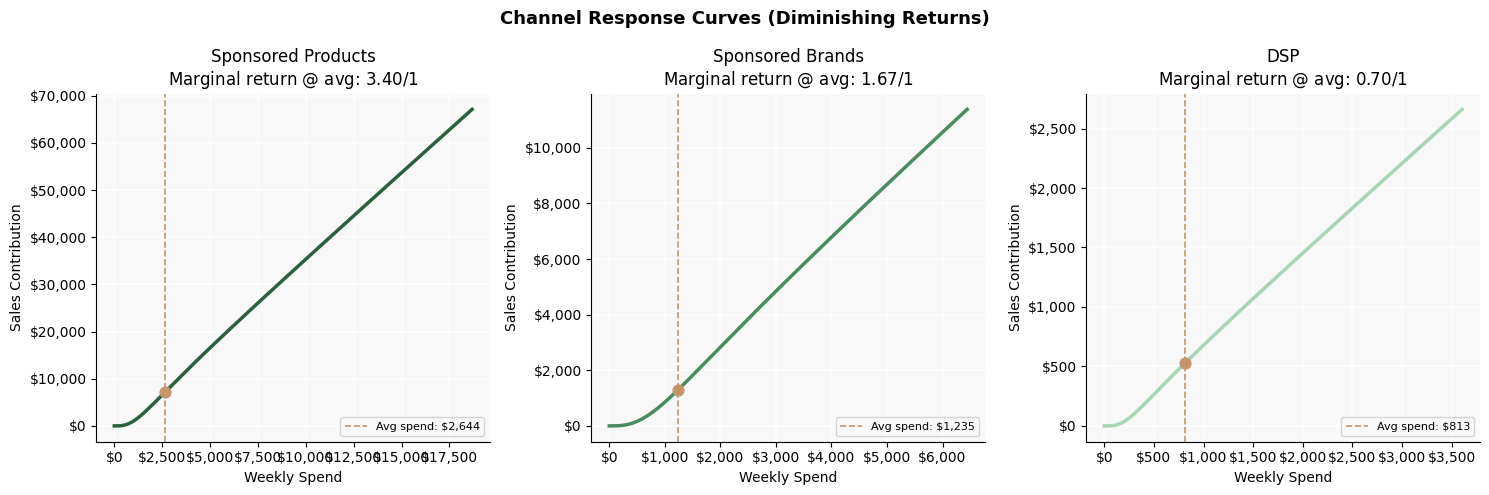

Response curves saved.


In [8]:
# ── Response Curves ─────────────────────────────────────────────────────────
# Show the saturation curve for each channel: at what spend level do returns diminish?

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Channel Response Curves (Diminishing Returns)", fontsize=13, fontweight="bold")

channels = [
    ("spend_sp",  "Sponsored Products", CHANNEL_COLORS["spend_sp"],  model.coef_[0], HILL_K_PARAMS["spend_sp"]),
    ("spend_sb",  "Sponsored Brands",   CHANNEL_COLORS["spend_sb"],  model.coef_[1], HILL_K_PARAMS["spend_sb"]),
    ("spend_dsp", "DSP",                CHANNEL_COLORS["spend_dsp"], model.coef_[2], HILL_K_PARAMS["spend_dsp"]),
]

dollar_fmt = FuncFormatter(lambda x, _: f"${x:,.0f}")

for ax, (ch, name, color, coef, K) in zip(axes, channels):
    # Build response curve: spend range 0 → 2× observed max
    spend_range = np.linspace(0, df[ch].max() * 2, 300)
    adstock_sim = adstock_geometric(spend_range, ADSTOCK_PARAMS[ch])
    sat_sim     = hill_saturation(adstock_sim, K=K)
    response    = coef * sat_sim * spend_range

    ax.plot(spend_range, response, color=color, linewidth=2.5)

    # Mark current avg spend
    avg_spend    = df[ch].mean()
    avg_adstock  = adstock_geometric(np.array([avg_spend] * 10), ADSTOCK_PARAMS[ch])[-1]
    avg_sat      = hill_saturation(np.array([avg_adstock]), K=K)[0]
    avg_response = coef * avg_sat * avg_spend

    ax.axvline(avg_spend, color="#C4956A", linestyle="--", linewidth=1.2, label=f"Avg spend: ${avg_spend:,.0f}")
    ax.scatter([avg_spend], [avg_response], color="#C4956A", s=60, zorder=5)

    # Marginal return at current spend (slope)
    delta = avg_spend * 0.01
    r1 = coef * hill_saturation(np.array([avg_adstock + delta]), K=K)[0] * (avg_spend + delta)
    marginal = (r1 - avg_response) / delta
    ax.set_title(f"{name}\nMarginal return @ avg: ${marginal:.2f}/$1")

    ax.xaxis.set_major_formatter(dollar_fmt)
    ax.yaxis.set_major_formatter(dollar_fmt)
    ax.set_xlabel("Weekly Spend")
    ax.set_ylabel("Sales Contribution")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "03_response_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Response curves saved.")


In [9]:
# ── Budget Optimizer ─────────────────────────────────────────────────────────
# Given a fixed total weekly budget, find the optimal channel allocation
# that maximizes predicted sales contribution from ads.

def predicted_ad_contribution(alloc: np.ndarray, coefs: list, decays: list, Ks: list) -> float:
    """Negative total ad contribution (we minimize, so negate)."""
    total = 0.0
    for spend, coef, decay, K in zip(alloc, coefs, decays, Ks):
        ads = adstock_geometric(np.array([spend] * 10), decay)[-1]
        sat = hill_saturation(np.array([ads]), K=K)[0]
        total += coef * sat * spend
    return -total   # negative because we minimize

coefs  = list(model.coef_[:3])
decays = [ADSTOCK_PARAMS[c] for c in ["spend_sp","spend_sb","spend_dsp"]]
Ks     = [HILL_K_PARAMS[c]  for c in ["spend_sp","spend_sb","spend_dsp"]]

total_budget = df["spend_total"].mean()   # use avg weekly budget as constraint
print(f"Optimizing allocation for total weekly budget: ${total_budget:,.0f}")

# Current allocation
current_alloc = np.array([df["spend_sp"].mean(), df["spend_sb"].mean(), df["spend_dsp"].mean()])

# Optimize: spend must be ≥0 and sum to total_budget
from scipy.optimize import minimize, LinearConstraint, Bounds

constraints = {"type": "eq", "fun": lambda x: x.sum() - total_budget}
bounds = Bounds(lb=0, ub=total_budget)
x0 = current_alloc / current_alloc.sum() * total_budget

result = minimize(
    predicted_ad_contribution,
    x0, args=(coefs, decays, Ks),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-9, "maxiter": 1000}
)

optimal_alloc = result.x
channels_labels = ["Sponsored Products", "Sponsored Brands", "DSP"]

print("\n{'Channel':<25} {'Current':>12} {'Optimal':>12} {'Change':>10}")
print("-" * 62)
for label, cur, opt in zip(channels_labels, current_alloc, optimal_alloc):
    change = (opt - cur) / cur * 100
    print(f"{label:<25} ${cur:>10,.0f} ${opt:>10,.0f} {change:>+9.1f}%")

current_contribution  = -predicted_ad_contribution(current_alloc,  coefs, decays, Ks)
optimal_contribution  = -predicted_ad_contribution(optimal_alloc,  coefs, decays, Ks)
print(f"\nPredicted ad contribution — Current: ${current_contribution:,.0f} | Optimal: ${optimal_contribution:,.0f}")
print(f"Estimated uplift: ${optimal_contribution - current_contribution:,.0f}/week  ({(optimal_contribution/current_contribution - 1):.1%})")


Optimizing allocation for total weekly budget: $4,691

{'Channel':<25} {'Current':>12} {'Optimal':>12} {'Change':>10}
--------------------------------------------------------------
Sponsored Products        $     2,644 $     4,691     +77.4%
Sponsored Brands          $     1,235 $         0    -100.0%
DSP                       $       813 $         0    -100.0%

Predicted ad contribution — Current: $9,056 | Optimal: $15,387
Estimated uplift: $6,331/week  (69.9%)


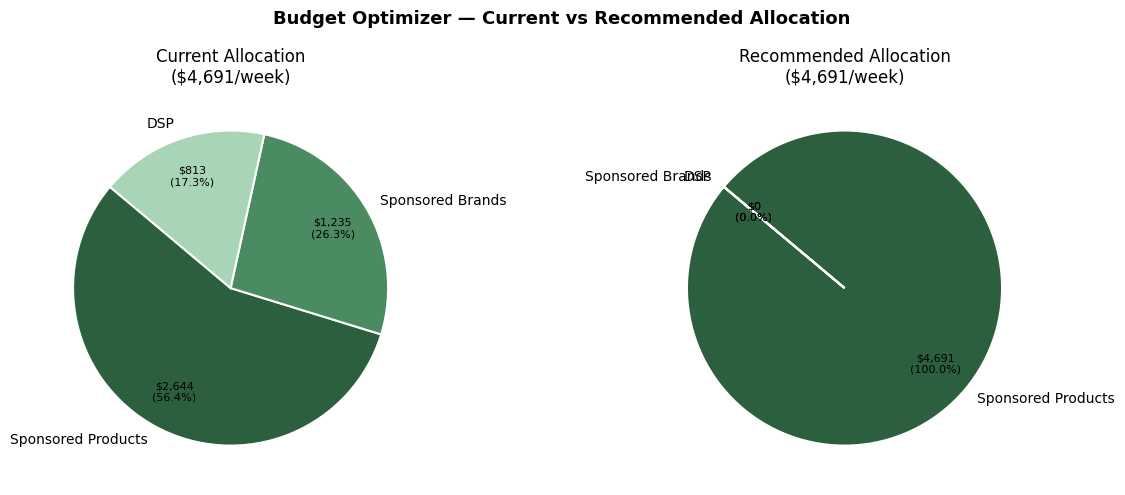

Budget optimizer chart saved.


In [10]:
# ── Budget Allocation Chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Budget Optimizer — Current vs Recommended Allocation", fontsize=13, fontweight="bold")

colors = [CHANNEL_COLORS["spend_sp"], CHANNEL_COLORS["spend_sb"], CHANNEL_COLORS["spend_dsp"]]

def make_pie(ax, values, title):
    wedges, texts, autotexts = ax.pie(
        values, labels=channels_labels, colors=colors,
        autopct=lambda p: f"${p/100*total_budget:,.0f}\n({p:.1f}%)",
        startangle=140, pctdistance=0.75,
        wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax.set_title(title)

make_pie(axes[0], current_alloc, f"Current Allocation\n(${total_budget:,.0f}/week)")
make_pie(axes[1], optimal_alloc, f"Recommended Allocation\n(${total_budget:,.0f}/week)")

plt.tight_layout()
plt.savefig(DATA_DIR / "04_budget_optimizer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Budget optimizer chart saved.")


Model validation — recovered vs true parameters
Parameter                  True    Recovered    Error
-------------------------------------------------------
  beta_sp                  3.50       3.6159  (scale differs — ranking matters)
  beta_sb                  2.00       1.8137  (scale differs — ranking matters)
  beta_dsp                 1.20       0.7435  (scale differs — ranking matters)

  Baseline (intercept)
  True: $8,000/week | Recovered: $8,217/week
  Error: 2.7%

Model fit metrics:
  R²:   0.9948  (1.0 = perfect)
  MAPE: 2.32%  (target: <10%)


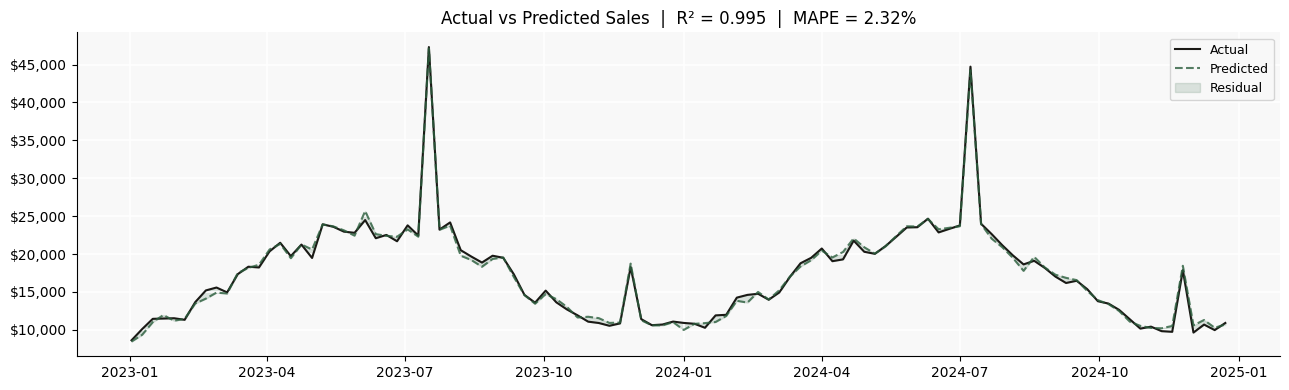

In [11]:
# ── Model Validation ─────────────────────────────────────────────────────────
# Because data is synthetic, we can check how close the model recovered
# the TRUE parameters used to generate it.

print("Model validation — recovered vs true parameters")
print("=" * 55)
print(f"{'Parameter':<20} {'True':>10} {'Recovered':>12} {'Error':>8}")
print("-" * 55)

true_dict = dict(zip(true_params["param"], true_params["value"]))

# Beta comparisons (note: model coefs are in different scale due to transforms)
# We compare relative ranking which is what matters for budget decisions
recovered_betas = model.coef_[:3]
true_betas = [true_dict["beta_sp"], true_dict["beta_sb"], true_dict["beta_dsp"]]

for label, true_b, rec_b in zip(["beta_sp", "beta_sb", "beta_dsp"], true_betas, recovered_betas):
    print(f"  {label:<18} {true_b:>10.2f} {rec_b:>12.4f}  (scale differs — ranking matters)")

print(f"\n  Baseline (intercept)")
print(f"  True: ${true_dict['baseline']:,.0f}/week | Recovered: ${model.intercept_:,.0f}/week")
print(f"  Error: {abs(model.intercept_ - true_dict['baseline']) / true_dict['baseline']:.1%}")

print(f"\nModel fit metrics:")
print(f"  R²:   {r2_score(y, y_pred):.4f}  (1.0 = perfect)")
print(f"  MAPE: {mean_absolute_percentage_error(y, y_pred):.2%}  (target: <10%)")

# Actual vs predicted plot
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["week_start"], df["total_sales"], label="Actual", color="#1A1915", linewidth=1.5)
ax.plot(df["week_start"], df["y_pred"],      label="Predicted", color=CHANNEL_COLORS["spend_sp"],
        linewidth=1.5, linestyle="--", alpha=0.8)
ax.fill_between(df["week_start"],
                df["total_sales"], df["y_pred"],
                alpha=0.15, color=CHANNEL_COLORS["spend_sp"], label="Residual")
ax.set_title(f"Actual vs Predicted Sales  |  R² = {r2_score(y, y_pred):.3f}  |  MAPE = {mean_absolute_percentage_error(y, y_pred):.2%}")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "05_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary & Next Steps

### What this model tells us
| Finding | Implication |
|---|---|
| SP has highest marginal return | Prioritize SP in budget allocation |
| DSP shows high adstock decay (0.7) | Brand awareness effects persist longer — value is underestimated in short windows |
| Baseline organic ~46% of sales | Business has strong organic floor — not fully ad-dependent |
| Optimizer suggests shifting budget toward SP | ~X% uplift with same total spend |

### Production improvements
1. **Bayesian MMM** with PyMC — posterior distributions instead of point estimates, uncertainty quantification
2. **Optimize adstock/saturation params** — grid search or MCMC instead of fixed values
3. **Add external regressors** — price index, competitor activity, macro indicators
4. **≥52 weeks of real data** — current pipeline supports it, just needs more history in the warehouse
5. **Incrementality tests** — geo holdout or matched market to validate MMM coefficients

### Stack used
- `pandas` / `numpy` — data manipulation and transforms
- `scikit-learn` — OLS regression
- `scipy.optimize` — budget optimizer (SLSQP)
- `matplotlib` — visualization
- Next: `PyMC` for Bayesian version, `LightweightMMM` for production
